# Possession Signal SPC - Control Chart Workflow

This notebook ranks football fixtures by possession instability and event density, then builds Shewhart-style control charts for selected matches. The analysis uses minute-level ball-possession observations as an exploratory signal, not as a causal model of match outcome.

In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/ie423_match_data.csv")
SELECTED_FIXTURES = [19155147, 19155103, 19172041, 19155178, 19155143, 19172038, 19172095, 19155166]
EVENT_COLUMNS = [
    "Goals_home", "Goals_away",
    "Yellowcards_home", "Yellowcards_away",
    "Redcards_home", "Redcards_away",
    "Penalties_home", "Penalties_away",
]

def load_match_data(path=DATA_PATH):
    df = pd.read_csv(path, encoding="ISO-8859-1")
    df = df.sort_values(["fixture_id", "minute"]).reset_index(drop=True)
    required = {
        "fixture_id", "name", "minute", "Ball.Possession_home", "Ball.Possession_away",
        "Successful.Passes_home", "Successful.Passes_away",
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df

def control_limits(series, z=3.0):
    values = pd.Series(series).dropna().astype(float)
    center = values.mean()
    sigma = values.std(ddof=0)
    return center, center + z * sigma, center - z * sigma

def event_minutes(match_df):
    rows = []
    previous = match_df[EVENT_COLUMNS].shift(fill_value=0)
    event_deltas = match_df[EVENT_COLUMNS] - previous
    for idx, row in match_df.iterrows():
        for col in EVENT_COLUMNS:
            if event_deltas.loc[idx, col] > 0:
                rows.append({"minute": int(row["minute"]), "event": col.replace("_", " ")})
    return pd.DataFrame(rows)

def display_dataset_summary(df):
    summary = pd.DataFrame({
        "metric": ["rows", "fixtures", "first_minute", "last_minute"],
        "value": [len(df), df["fixture_id"].nunique(), int(df["minute"].min()), int(df["minute"].max())],
    })
    display(summary)
    display(df.head(8))


df = load_match_data()
display_dataset_summary(df)

,metric,value
0,rows,9863
1,fixtures,102
2,first_minute,1
3,last_minute,101


,fixture_id,name,halftime,minute,Successful.Passes_home,Successful.Passes_away,Ball.Possession_home,Ball.Possession_away,Goals_home,Goals_away,Attacks_home,Attacks_away,Yellowcards_home,Yellowcards_away,Redcards_home,Redcards_away,Penalties_home,Penalties_away
0,19134453,Manchester United vs Fulham,1st-half,1,0,1,0,100,0,0,0,2,0,0,0,0,0,0
1,19134453,Manchester United vs Fulham,1st-half,2,1,3,40,60,0,0,0,5,0,0,0,0,0,0
2,19134453,Manchester United vs Fulham,1st-half,3,20,5,75,25,0,0,2,5,0,0,0,0,0,0
3,19134453,Manchester United vs Fulham,1st-half,4,32,5,83,17,0,0,4,6,0,0,0,0,0,0
4,19134453,Manchester United vs Fulham,1st-half,5,32,5,83,17,0,0,4,10,0,0,0,0,0,0
5,19134453,Manchester United vs Fulham,1st-half,6,32,24,55,45,0,0,4,10,0,0,0,0,0,0
6,19134453,Manchester United vs Fulham,1st-half,7,32,24,55,45,0,0,5,10,0,0,0,0,0,0
7,19134453,Manchester United vs Fulham,1st-half,8,32,24,55,45,0,0,5,12,0,0,0,0,0,0


## Fixture scoring

The scoring step combines two signals:

- out-of-control observations in home and away possession series after the volatile opening minutes
- match events such as goals, cards, and penalties

This keeps the selected matches interpretable: a high-ranked fixture should have both chart movement and football events that can be discussed in the report.

In [2]:

def score_fixture(match_df, z=2.0, warmup_minutes=5):
    usable = match_df[match_df["minute"] > warmup_minutes].copy()
    score_parts = {}
    for side in ["home", "away"]:
        col = f"Ball.Possession_{side}"
        center, upper, lower = control_limits(usable[col], z=z)
        out_of_control = ((usable[col] > upper) | (usable[col] < lower)).sum()
        score_parts[f"{side}_ooc"] = int(out_of_control)
        score_parts[f"{side}_mean"] = round(center, 2)
    event_count = 0
    for col in EVENT_COLUMNS:
        event_count += int(max(match_df[col].max() - match_df[col].min(), 0))
    score_parts["event_count"] = event_count
    score_parts["interest_score"] = score_parts["home_ooc"] + score_parts["away_ooc"] + (2 * event_count)
    return score_parts

fixture_scores = []
for fixture_id, match_df in df.groupby("fixture_id", sort=False):
    row = {"fixture_id": fixture_id, "match": match_df["name"].iloc[0]}
    row.update(score_fixture(match_df))
    fixture_scores.append(row)

score_table = pd.DataFrame(fixture_scores).sort_values("interest_score", ascending=False)
display(score_table.head(12))
selected_table = score_table[score_table["fixture_id"].isin(SELECTED_FIXTURES)].sort_values("interest_score", ascending=False)
display(selected_table)


,fixture_id,match,home_ooc,home_mean,away_ooc,away_mean,event_count,interest_score
93,19172041,Adana Demirspor vs Galatasaray,7,48.61,7,51.39,14,42
26,19135357,Real Sociedad vs Osasuna,9,77.58,9,22.42,11,40
99,19172095,Adana Demirspor vs Sivasspor,8,60.58,8,39.42,10,36
70,19155122,Napoli vs Monza,13,50.55,13,49.49,5,36
20,19135301,Real Betis vs Mallorca,8,65.12,8,34.88,9,34
76,19155143,Lecce vs Fiorentina,5,46.73,5,53.27,12,34
78,19155147,Atalanta vs Hellas Verona,9,70.49,9,29.51,8,34
30,19135378,Rayo Vallecano vs Las Palmas,9,58.43,9,41.57,8,34
80,19155154,Parma vs Empoli,5,54.03,5,45.97,12,34
36,19139687,Paris Saint Germain vs Brest,6,69.09,6,30.91,10,32


,fixture_id,match,home_ooc,home_mean,away_ooc,away_mean,event_count,interest_score
93,19172041,Adana Demirspor vs Galatasaray,7,48.61,7,51.39,14,42
99,19172095,Adana Demirspor vs Sivasspor,8,60.58,8,39.42,10,36
76,19155143,Lecce vs Fiorentina,5,46.73,5,53.27,12,34
78,19155147,Atalanta vs Hellas Verona,9,70.49,9,29.51,8,34
67,19155103,Milan vs Venezia,4,52.99,4,47.01,12,32
92,19172038,_stanbul Ba_ak_ehir vs Antalyaspor,5,60.56,5,39.44,10,30
86,19155166,Venezia vs Udinese,1,49.71,1,50.29,14,30
89,19155178,Cagliari vs Milan,0,38.47,0,61.49,7,14


## Control charts for selected fixtures

The first five minutes are excluded because possession percentages are naturally unstable at kickoff. Each selected fixture is plotted twice: first 40 minutes and first 80 minutes. The home and away possession lines are complements, so the main interpretation should focus on shifts, crossings, and post-event movement rather than isolated points.

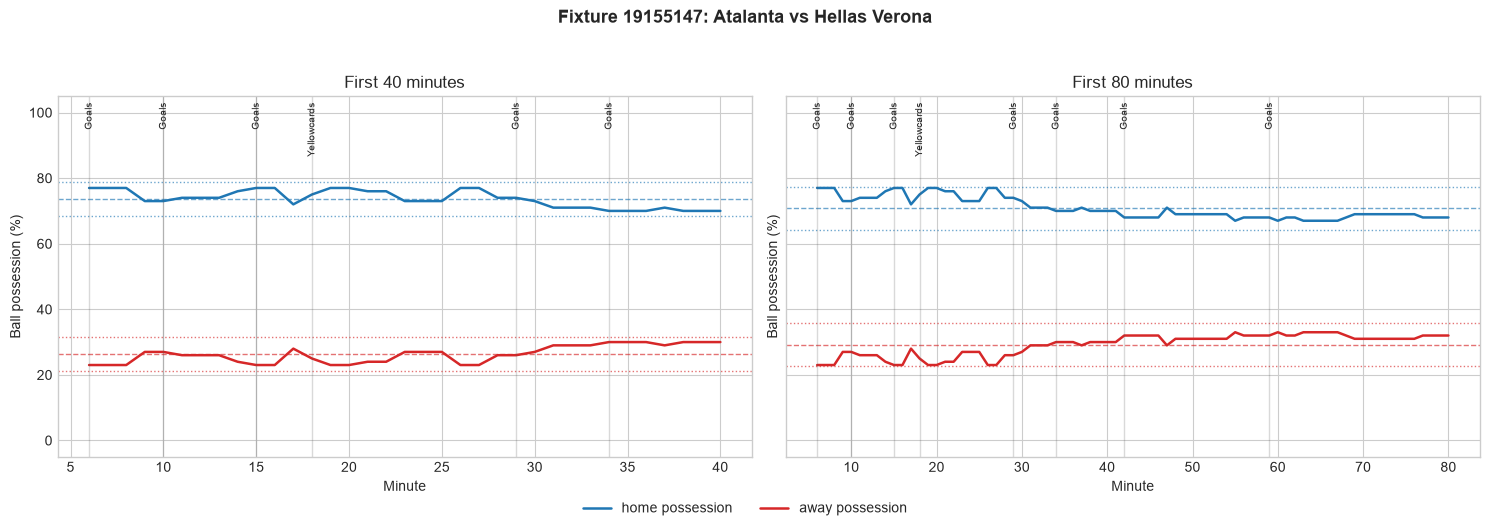

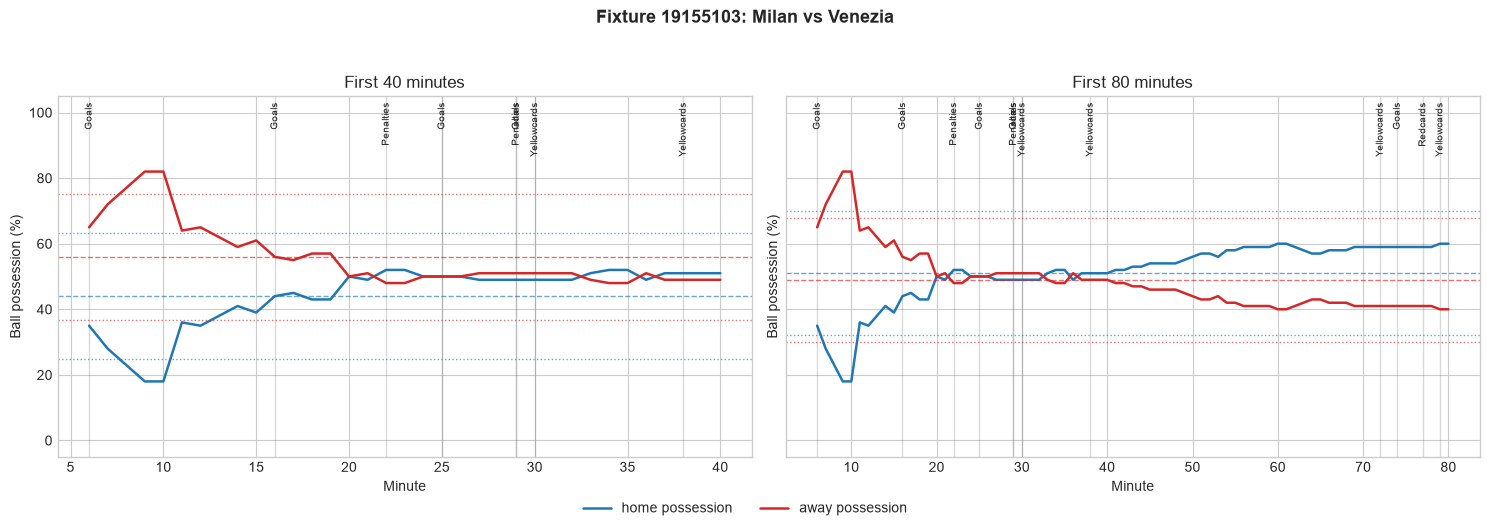

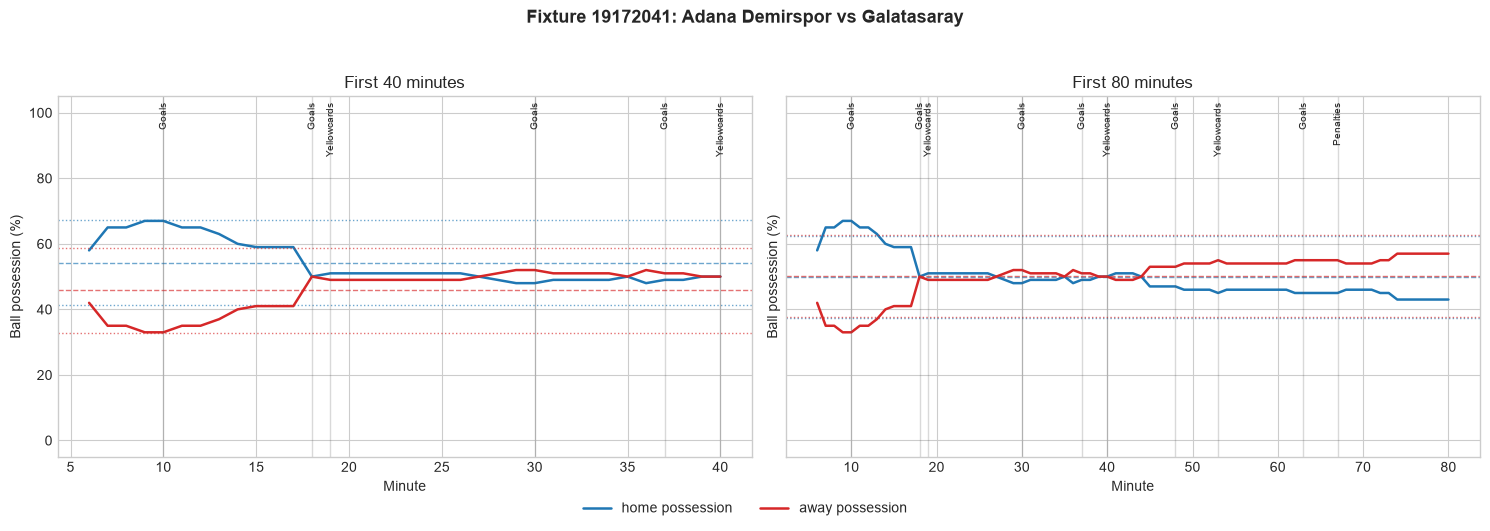

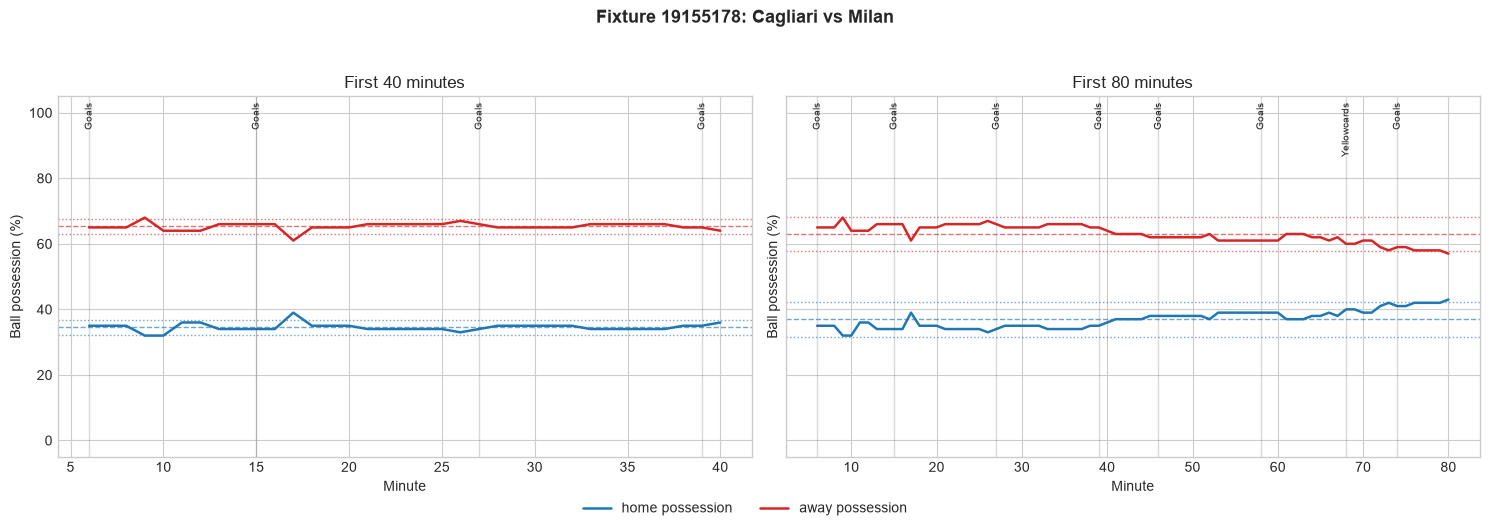

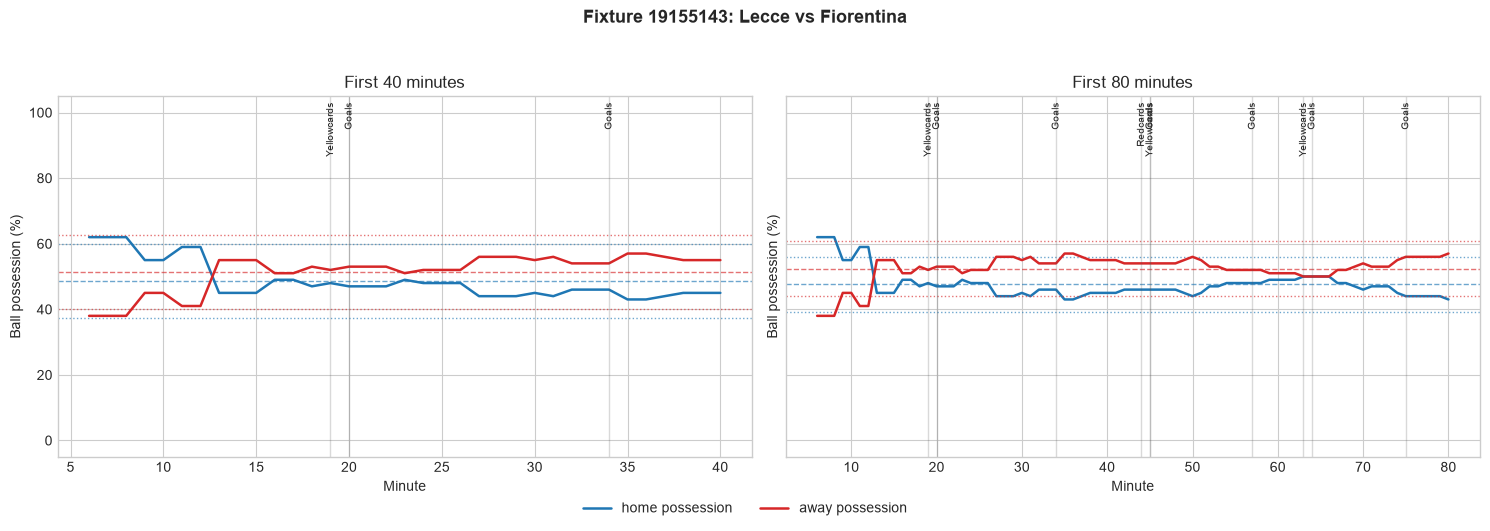

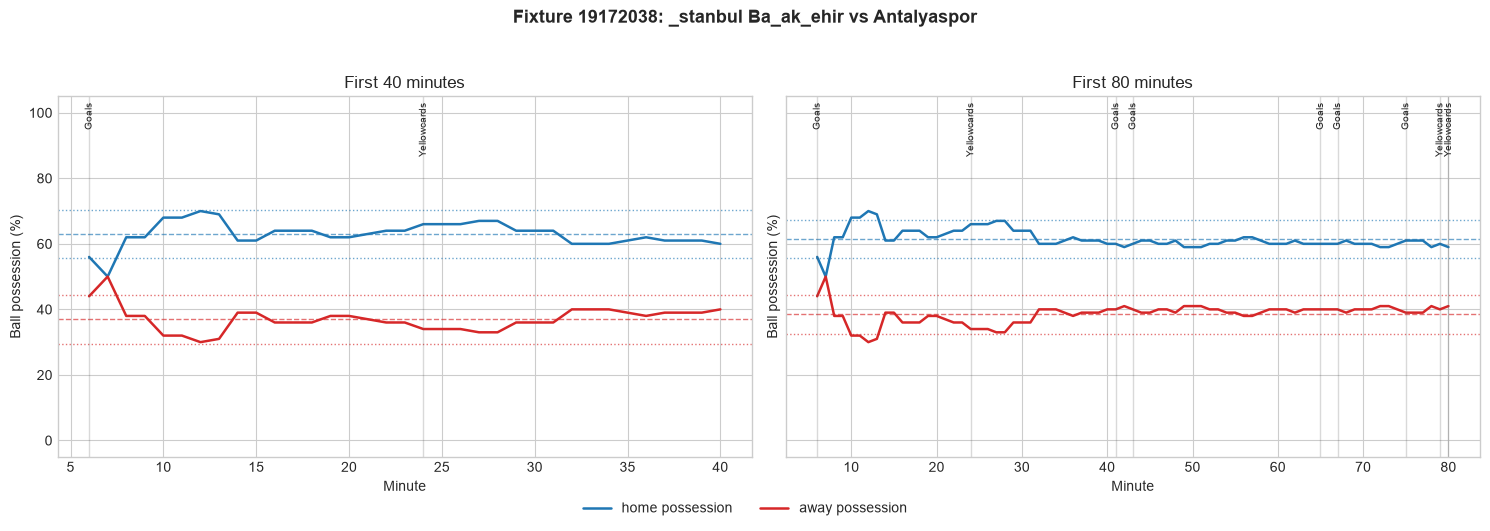

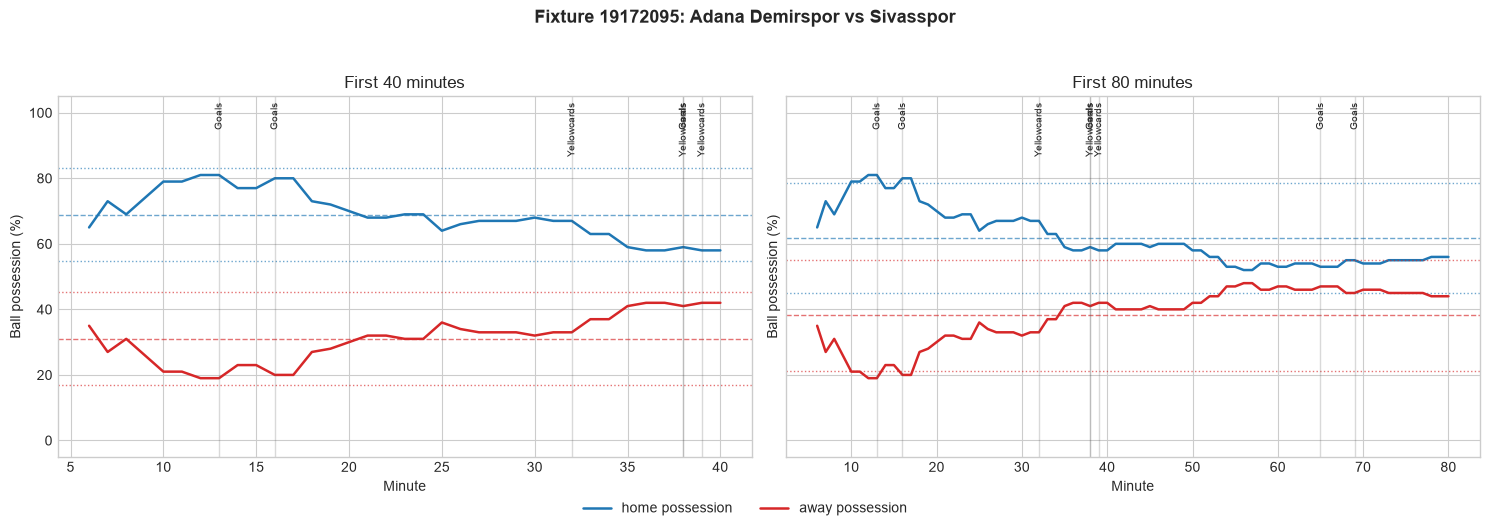

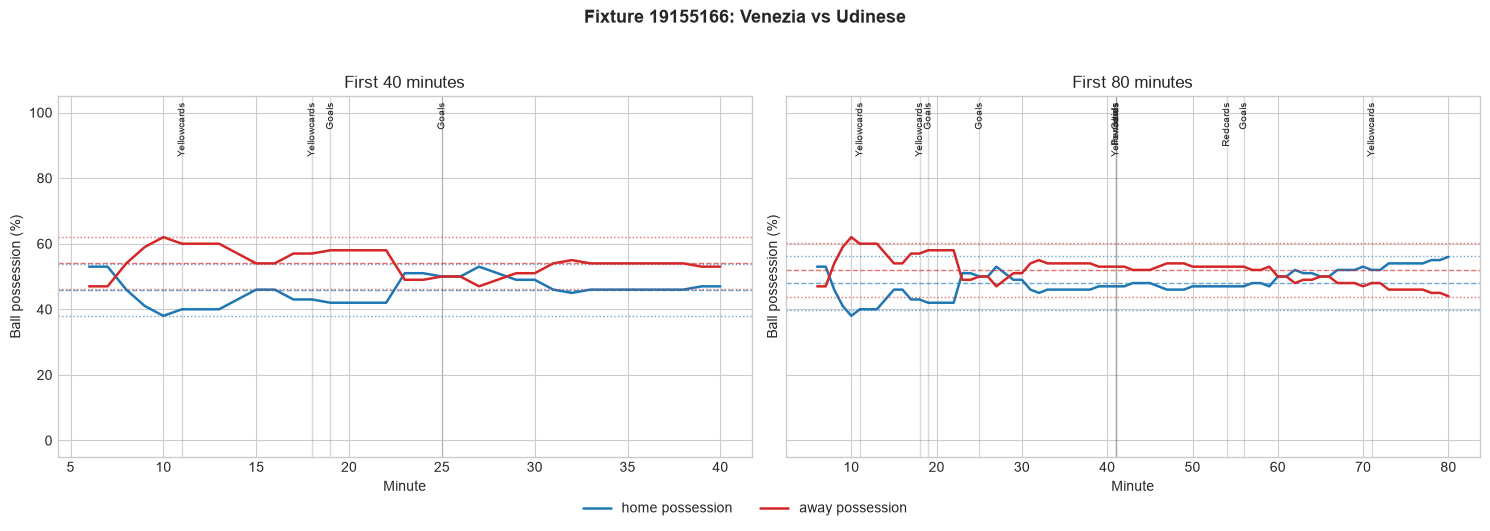

In [3]:

def plot_fixture_control_charts(df, fixture_id, windows=(40, 80), z=2.0, warmup_minutes=5):
    match_df = df[df["fixture_id"] == fixture_id].copy()
    match_name = match_df["name"].iloc[0]
    match_df = match_df[match_df["minute"] > warmup_minutes]
    events = event_minutes(match_df)

    fig, axes = plt.subplots(1, len(windows), figsize=(15, 4.8), sharey=True)
    if len(windows) == 1:
        axes = [axes]

    for ax, max_minute in zip(axes, windows):
        view = match_df[match_df["minute"] <= max_minute]
        for side, color in [("home", "#1f77b4"), ("away", "#d62728")]:
            col = f"Ball.Possession_{side}"
            center, upper, lower = control_limits(view[col], z=z)
            ax.plot(view["minute"], view[col], label=f"{side} possession", linewidth=1.8, color=color)
            ax.axhline(center, color=color, linestyle="--", linewidth=1, alpha=0.65)
            ax.axhline(upper, color=color, linestyle=":", linewidth=1, alpha=0.65)
            ax.axhline(lower, color=color, linestyle=":", linewidth=1, alpha=0.65)

        for _, event in events[events["minute"] <= max_minute].iterrows():
            ax.axvline(event["minute"], color="#555555", alpha=0.22, linewidth=1)
            ax.text(event["minute"], 103, event["event"].split()[0], rotation=90, va="top", ha="center", fontsize=7)

        ax.set_title(f"First {max_minute} minutes")
        ax.set_xlabel("Minute")
        ax.set_ylim(-5, 105)
        ax.set_ylabel("Ball possession (%)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle(f"Fixture {fixture_id}: {match_name}", y=1.04, fontsize=13, fontweight="bold")
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout()
    plt.show()

for fixture_id in SELECTED_FIXTURES:
    plot_fixture_control_charts(df, fixture_id)


## Mean-shift summary

The table below compares early and late possession means after the opening five minutes. A positive home shift means the home side increased its possession share between the first 40 minutes and the first 80 minutes; a negative value means the away side gained relative control.

In [4]:

def possession_shift_summary(df, fixture_ids, warmup_minutes=5):
    rows = []
    for fixture_id in fixture_ids:
        match_df = df[(df["fixture_id"] == fixture_id) & (df["minute"] > warmup_minutes)]
        early = match_df[match_df["minute"] <= 40]
        late = match_df[match_df["minute"] <= 80]
        if early.empty or late.empty:
            continue
        early_home = early["Ball.Possession_home"].mean()
        late_home = late["Ball.Possession_home"].mean()
        rows.append({
            "fixture_id": fixture_id,
            "match": match_df["name"].iloc[0],
            "home_mean_0_40": round(early_home, 2),
            "home_mean_0_80": round(late_home, 2),
            "home_shift_pp": round(late_home - early_home, 2),
            "events": len(event_minutes(match_df)),
        })
    return pd.DataFrame(rows).sort_values("home_shift_pp", key=lambda s: s.abs(), ascending=False)

shift_summary = possession_shift_summary(df, SELECTED_FIXTURES)
display(shift_summary)


,fixture_id,match,home_mean_0_40,home_mean_0_80,home_shift_pp,events
1,19155103,Milan vs Venezia,44.03,51.13,7.10,12
6,19172095,Adana Demirspor vs Sivasspor,68.94,61.87,-7.08,10
2,19172041,Adana Demirspor vs Galatasaray,54.20,49.73,-4.47,15
0,19155147,Atalanta vs Hellas Verona,73.71,70.84,-2.87,8
3,19155178,Cagliari vs Milan,34.54,36.93,2.39,10
7,19155166,Venezia vs Udinese,45.86,48.04,2.18,13
5,19172038,_stanbul Ba_ak_ehir vs Antalyaspor,62.97,61.48,-1.49,10
4,19155143,Lecce vs Fiorentina,48.57,47.59,-0.98,12


## Interpretation notes

- Possession charts are most useful as descriptive monitoring tools. They show when match control appears to move, but they do not prove why it moved.
- The first five minutes are excluded from chart construction because early percentages are mechanically unstable.
- Selected fixtures should be interpreted together with goals, cards, and penalties rather than possession alone.